In [2]:
from tensorflow.keras.models import load_model
model = load_model("broiler_model.keras")

/home/takudzwa/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



✅ Predicted disease: cocci
🔢 Probability: 0.7482

Total probability: 1.000000
📊 Class probabilities:
cocci: 0.7482
healthy: 0.0494
ncd: 0.0411
others: 0.1613


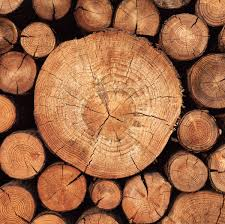

In [38]:
# TESTING THE TFLITE MODEL
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os
from PIL import Image
from IPython.display import display

# Load the TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="broiler_model.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get class names from your training folder
class_names = sorted(os.listdir("../FOMO/dataset/train"))

# Load and preprocess the image
def predict_image(image_path):
    img = image.load_img(image_path, target_size=(96, 96))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize

    interpreter.set_tensor(input_details[0]['index'], img_array.astype(np.float32))
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])

    probabilities = output_data[0]  # Already softmaxed by the model

    predicted_class_index = np.argmax(probabilities)
    predicted_class_name = class_names[predicted_class_index]
    predicted_probability = probabilities[predicted_class_index]

  

    return predicted_class_name, predicted_probability, probabilities


# Select the image to test
image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/practice/wood.jpeg"

# Run prediction
predicted_class_name, predicted_probability, all_probs = predict_image(image_path)

# Print prediction
print(f"\n✅ Predicted disease: {predicted_class_name}")
print(f"🔢 Probability: {predicted_probability:.4f}\n")
print(f"Total probability: {np.sum(all_probs):.6f}")


# Print all class probabilities
print("📊 Class probabilities:")
for i, prob in enumerate(all_probs):
    print(f"{class_names[i]}: {prob:.4f}")
    

# Display the image
display_img = Image.open(image_path)
display(display_img)


In [25]:
# # previous


# #TESTING THE MODEL


# import tensorflow as tf
# from tensorflow.keras.preprocessing import image
# import numpy as np
# import os
# from PIL import Image
# from IPython.display import display

# # Load the TensorFlow Lite model
# interpreter = tf.lite.Interpreter(model_path="/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite")
# interpreter.allocate_tensors()

# # Get input and output tensors.
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()

# # Load and preprocess the image
# def predict_image(image_path):
#     img = image.load_img(image_path, target_size=(96, 96))
#     img_array = image.img_to_array(img)
#     img_array = np.expand_dims(img_array, axis=0)
#     img_array = img_array / 255.0

#     interpreter.set_tensor(input_details[0]['index'], img_array.astype(np.float32))
#     interpreter.invoke()
#     output_data = interpreter.get_tensor(output_details[0]['index'])
#     return output_data


# class_names = sorted(os.listdir("../FOMO/dataset/train")) 

# # image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/healthy/healthy.472.jpg" 
# # image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/ncd/ncd.256.jpg" 
# # image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/cocci/cocci.492.jpg" 
# image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/practice/healthy.jpeg" 




# # Get the prediction
# predictions = predict_image(image_path)
# predicted_class_index = np.argmax(predictions, axis=1)[0]
# predicted_probability = predictions[0][predicted_class_index]
# predicted_class_name = class_names[predicted_class_index]

# # Print the results
# print(f"Predicted disease: {predicted_class_name}")
# print(f"Probability: {predicted_probability:.4f}")

# # Display the image in the notebook
# display_img = Image.open(image_path)
# display(display_img) # Use display() instead of show()